# 4 - Word Frequency Visualization


In [1]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
def lower_case(text):
  text = text.lower()
  return text

In [3]:
def remove_punctuation(text):
  punctuation_pattern = r'[^\w\s]'
  text_cleaned = re.sub(punctuation_pattern, '', text)
  return text_cleaned

In [4]:
def remove_whitespace(text):
  text_cleaned = " ".join(text.split())
  return text_cleaned

In [5]:
def remove_stopwords(text, language):
  stop_words = set(stopwords.words(language))
  text = text.lower()
  words_token = text.split()
  filtered_text = [word for word in words_token if word.lower() not in stop_words]
  filtered_text = " ".join(filtered_text)
  return filtered_text

In [6]:
def word_token_conv(text):
  sample_text = text
  token = word_tokenize(sample_text)
  return token

In [7]:
file_path = '/content/1789-Washington.txt'
with open(file_path, 'r', encoding='utf-8') as file:
    text_data = file.read()

In [8]:
text_data = lower_case(text_data)
text_data = remove_punctuation(text_data)
text_data = remove_stopwords(text_data, 'english')
text_data = remove_whitespace(text_data)
text_data = word_tokenize(text_data)
print(text_data)

['fellowcitizens', 'senate', 'house', 'representatives', 'among', 'vicissitudes', 'incident', 'life', 'event', 'could', 'filled', 'greater', 'anxieties', 'notification', 'transmitted', 'order', 'received', '14th', 'day', 'present', 'month', 'one', 'hand', 'summoned', 'country', 'whose', 'voice', 'never', 'hear', 'veneration', 'love', 'retreat', 'chosen', 'fondest', 'predilection', 'flattering', 'hopes', 'immutable', 'decision', 'asylum', 'declining', 'years', 'retreat', 'rendered', 'every', 'day', 'necessary', 'well', 'dear', 'addition', 'habit', 'inclination', 'frequent', 'interruptions', 'health', 'gradual', 'waste', 'committed', 'time', 'hand', 'magnitude', 'difficulty', 'trust', 'voice', 'country', 'called', 'sufficient', 'awaken', 'wisest', 'experienced', 'citizens', 'distrustful', 'scrutiny', 'qualifications', 'could', 'overwhelm', 'despondence', 'one', 'inheriting', 'inferior', 'endowments', 'nature', 'unpracticed', 'duties', 'civil', 'administration', 'ought', 'peculiarly', 'co

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
dic = {"Words" : text_data}
df = pd.DataFrame(dic)
df

,Words
0,fellowcitizens
1,senate
2,house
3,representatives
4,among
...,...
643,measures
644,success
645,government
646,must


In [11]:
df['Words'].value_counts()

,count
Words,
every,9
government,8
may,6
public,6
country,5
...,...
leave,1
take,1
together,1


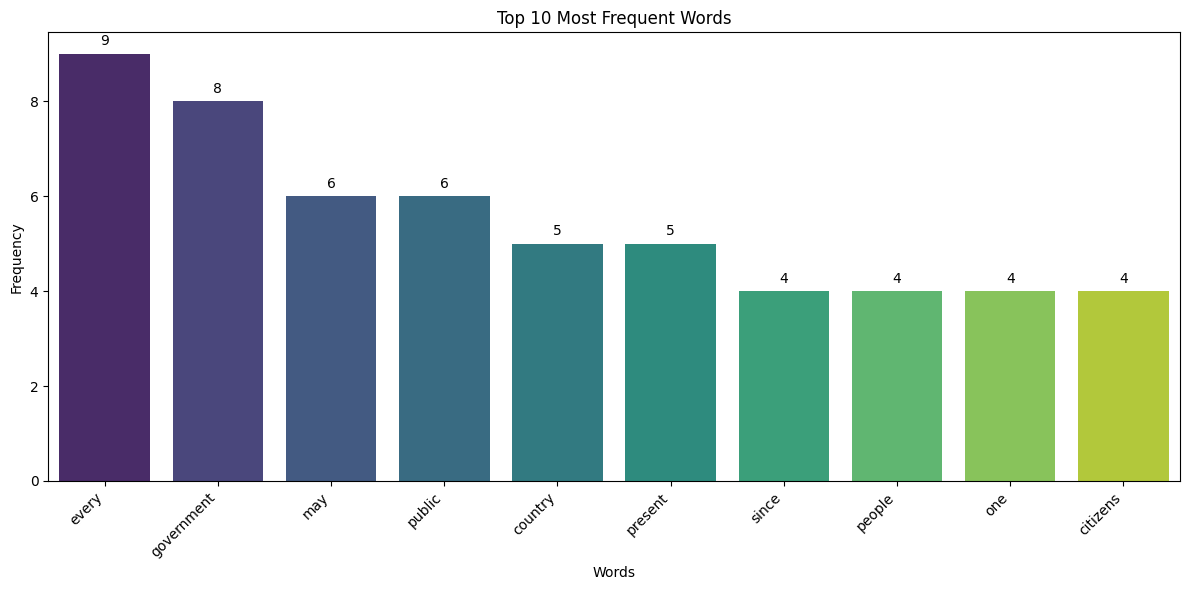

In [13]:
top_10_words = df['Words'].value_counts().head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10_words.index, y=top_10_words.values, palette='viridis', hue=top_10_words.index, legend=False)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

## Conclusion

Firstly, dataset is cleaned. Afterthat, The most common words are shown in bar graph.  
It is found that the word "every" and "government" are used most of the time.

# 5 - Loss Function Tracking

### Binary Cross-Entropy Loss Calculation and Visualization

This section defines a binary cross-entropy loss function, simulates training data over 10 epochs, calculates the loss for each epoch, and visualizes the loss trend with a line chart.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

In [15]:
n_epochs = 10
losses = []

y_true_sample = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])

np.random.seed(42)

for epoch in range(n_epochs):
  if epoch == 0:
      y_pred_epoch = np.random.rand(len(y_true_sample)) # Start with random predictions
  else:

      improvement_factor = 0.05 * epoch
      y_pred_epoch = np.clip(y_pred_epoch + (y_true_sample - y_pred_epoch) * improvement_factor, 0.05, 0.95)
  current_loss = binary_cross_entropy(y_true_sample, y_pred_epoch)
  losses.append(current_loss)

  print(f"Epoch {epoch+1}: Loss = {current_loss:.4f}")

Epoch 1: Loss = 1.1754
Epoch 2: Loss = 0.9908
Epoch 3: Loss = 0.7741
Epoch 4: Loss = 0.5794
Epoch 5: Loss = 0.4170
Epoch 6: Loss = 0.2875
Epoch 7: Loss = 0.1893
Epoch 8: Loss = 0.1211
Epoch 9: Loss = 0.0770
Epoch 10: Loss = 0.0545


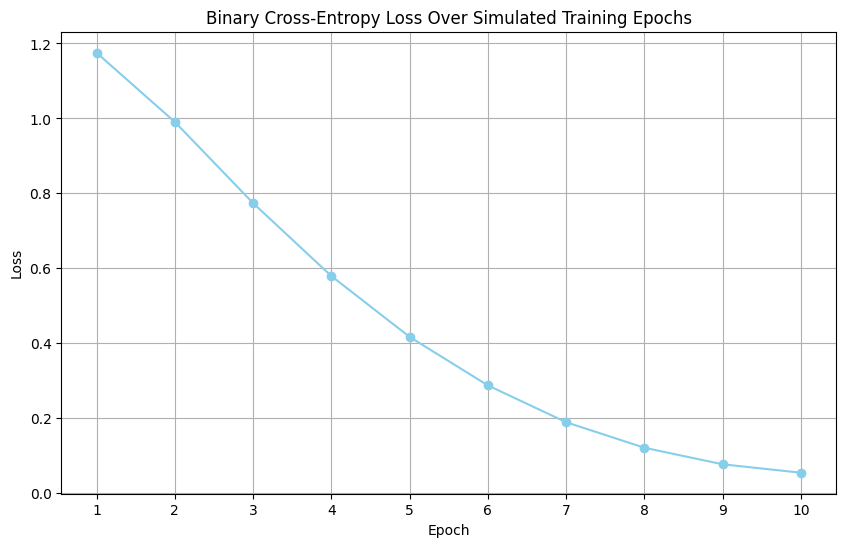

In [16]:
# Visualize the loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), losses, marker='o', linestyle='-', color='skyblue')
plt.title('Binary Cross-Entropy Loss Over Simulated Training Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, n_epochs + 1))
plt.show()